In [1]:
import os
import sys
from pathlib import Path

library_path = os.path.abspath('../../src')
if library_path not in sys.path:
    sys.path.append(library_path)
library_path = Path(library_path)

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

DATA_PATH = library_path.parent / "data"
PLOTS_PATH = library_path.parent / "plots"
PLOTS_PATH.mkdir(parents=True, exist_ok=True)

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.float_format", lambda x: f"{x:.3f}")

## Within-HSE Consistency Check: HSE 2017 vs HSE 2018

### Rationale

The norm derivation pipeline (notebook 04) uses **HSE 2017 and HSE 2018** as the
reference/target distribution. HSE 2019 is excluded because it has no EQ-5D-5L outcome
data. Before deriving norms, we need to verify that these two waves are internally
consistent — i.e., that pooling them as a single reference does not introduce
artefactual distributional shift.

This check uses the **15-variable predictor set** for notebook 04, which extends the
13-variable set from notebook 03 by adding `resp` and `skin` (both 0% missing in
HSE 2017–18 and DAPHNIE 2024 once HSE 2019 is excluded from the target).

The standard threshold for meaningful imbalance is $|\text{SMD}| > 0.1$. Variables
exceeding this between 2017 and 2018 would indicate wave-specific composition effects
that should be acknowledged when interpreting the pooled reference norms.

SMD is computed as (HSE 2018 − HSE 2017), using survey weights (`wt_int`) for both
waves. Positive values indicate higher prevalence/mean in 2018.

In [3]:
df = pd.read_csv(DATA_PATH / "wrangled_data.csv", low_memory=False)

hse17 = df[df["dataset"] == "HSE 2017"].copy()
hse18 = df[df["dataset"] == "HSE 2018"].copy()

print(f"HSE 2017: n = {len(hse17):,}")
print(f"HSE 2018: n = {len(hse18):,}")

HSE 2017: n = 7,996
HSE 2018: n = 8,177


In [4]:
# 15-variable predictor set for notebook 04
# 13 from notebook 03 (confirmed by PI) + resp + skin
FEATURES = [
    "Sex", "age7cat",
    "eth2cat", "alcohol_yr",
    "emp_cat_Employed", "emp_cat_Other (Sick/Home/etc)", "emp_cat_Retired",
    "emp_cat_Student", "emp_cat_Unemployed",
    "edu_cat_2",
    "smoke_ecig", "diabetes",
    "meds_num", "ill_dis",
    "resp", "skin",
]
FEATURES = [f for f in FEATURES if f in df.columns]
print(f"Features ({len(FEATURES)}):")
print(FEATURES)

# Confirm no missing values in either wave
print("\nMissingness check:")
miss = pd.DataFrame({
    "HSE 2017 miss%": hse17[FEATURES].isna().mean() * 100,
    "HSE 2018 miss%": hse18[FEATURES].isna().mean() * 100,
}).round(1)
display(miss[miss.max(axis=1) > 0] if (miss.max(axis=1) > 0).any() else "No missing values in either wave.")

Features (16):
['Sex', 'age7cat', 'eth2cat', 'alcohol_yr', 'emp_cat_Employed', 'emp_cat_Other (Sick/Home/etc)', 'emp_cat_Retired', 'emp_cat_Student', 'emp_cat_Unemployed', 'edu_cat_2', 'smoke_ecig', 'diabetes', 'meds_num', 'ill_dis', 'resp', 'skin']

Missingness check:


,HSE 2017 miss%,HSE 2018 miss%
eth2cat,0.400,0.300
alcohol_yr,17.100,16.800
edu_cat_2,0.500,0.500
meds_num,35.100,41.000


In [5]:
def weighted_mean(series, weights):
    mask = series.notna() & weights.notna() & (weights > 0)
    if mask.sum() == 0:
        return np.nan
    s, w = series[mask], weights[mask]
    return np.average(s, weights=w)


def weighted_var(series, weights):
    mask = series.notna() & weights.notna() & (weights > 0)
    if mask.sum() < 2:
        return np.nan
    s, w = series[mask], weights[mask]
    mu = np.average(s, weights=w)
    return np.average((s - mu) ** 2, weights=w)


def compute_smd(source_series, source_weights, target_series, target_weights):
    mu_s = weighted_mean(source_series, source_weights)
    mu_t = weighted_mean(target_series, target_weights)
    if np.isnan(mu_s) or np.isnan(mu_t):
        return np.nan
    var_s = weighted_var(source_series, source_weights)
    var_t = weighted_var(target_series, target_weights)
    if np.isnan(var_s) or np.isnan(var_t):
        return np.nan
    pooled_sd = np.sqrt((var_s + var_t) / 2)
    if pooled_sd == 0:
        return np.nan
    return (mu_s - mu_t) / pooled_sd

In [6]:
wt17 = hse17["wt_int"].fillna(1.0)
wt18 = hse18["wt_int"].fillna(1.0)

smds = {
    col: compute_smd(hse18[col], wt18, hse17[col], wt17)
    for col in FEATURES
}

smd_series = (
    pd.Series(smds, name="SMD (2018 − 2017)")
    .sort_values(key=abs, ascending=False)
)

print("SMD table (positive = higher in HSE 2018 than HSE 2017):")
display(smd_series.round(3).to_frame())

SMD table (positive = higher in HSE 2018 than HSE 2017):


,SMD (2018 − 2017)
eth2cat,0.037
emp_cat_Student,0.030
emp_cat_Employed,-0.025
emp_cat_Other (Sick/Home/etc),0.021
edu_cat_2,-0.017
alcohol_yr,-0.015
diabetes,0.015
smoke_ecig,0.013
ill_dis,-0.011
meds_num,-0.009


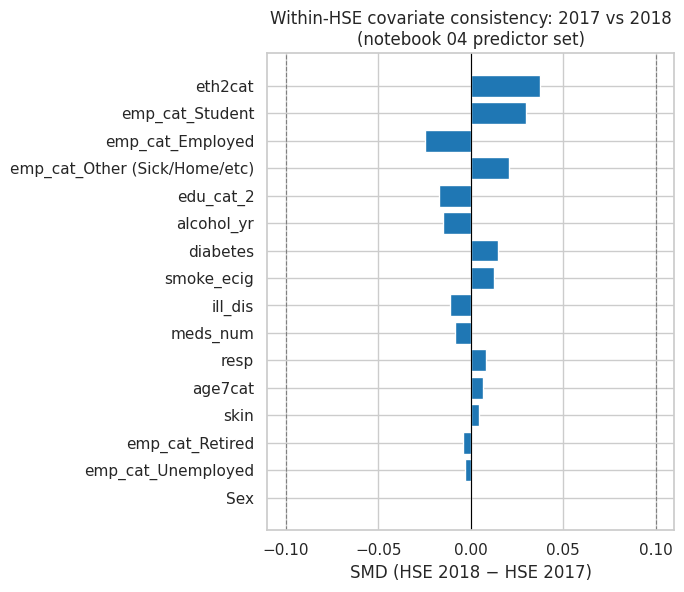

In [7]:
smds_plot = smd_series.dropna().sort_values(key=abs)
colors = ["#d62728" if abs(v) > 0.1 else "#1f77b4" for v in smds_plot]

fig, ax = plt.subplots(figsize=(7, max(5, len(smds_plot) * 0.38)))
ax.barh(smds_plot.index, smds_plot.values, color=colors)
ax.axvline(0,    color="black", linewidth=0.8)
ax.axvline( 0.1, color="grey",  linewidth=0.8, linestyle="--")
ax.axvline(-0.1, color="grey",  linewidth=0.8, linestyle="--")
ax.set_xlabel("SMD (HSE 2018 − HSE 2017)")
ax.set_title("Within-HSE covariate consistency: 2017 vs 2018\n(notebook 04 predictor set)")
plt.tight_layout()
plt.savefig(PLOTS_PATH / "love_plot_hse_2017_vs_2018.png", dpi=150, bbox_inches="tight")
plt.show()

In [8]:
valid = smd_series.dropna()
imbalanced = valid[valid.abs() > 0.1].sort_values(key=abs, ascending=False)

print(f"Variables with |SMD| > 0.1: {len(imbalanced)} / {len(valid)}")

if len(imbalanced) == 0:
    print("\nAll predictor variables are well-balanced between HSE 2017 and HSE 2018.")
    print("Pooling the two waves as a single reference distribution for notebook 04 is supported.")
else:
    print("\nVariables exceeding |SMD| > 0.1 between HSE 2017 and HSE 2018:")
    display(imbalanced.round(3).to_frame())
    print("\nThese wave-specific differences should be acknowledged when interpreting")
    print("the pooled reference norms derived in notebook 04.")

Variables with |SMD| > 0.1: 0 / 16

All predictor variables are well-balanced between HSE 2017 and HSE 2018.
Pooling the two waves as a single reference distribution for notebook 04 is supported.
